In [1]:
from random import seed
from algoritmo import juego

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp

from util import time_algorithm

seed(12345)
np.random.seed(12345)

sns.set_theme()

In [2]:
def get_random_array(size: int):
    return np.random.randint(0, 100000, size)

x = np.linspace(100, 10_000_000, 20).astype(int)

results = time_algorithm(juego, x, lambda s: [get_random_array(s)])

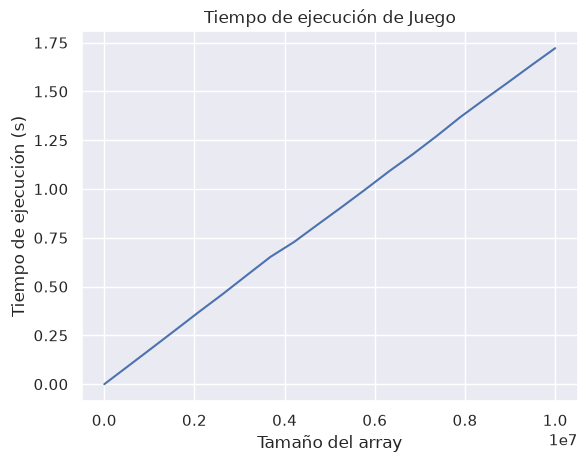

In [3]:
fig, ax = plt.subplots()
ax.plot(x, [results[i] for i in x], label="Medición")
ax.set_title('Tiempo de ejecución de Juego')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')
None

In [4]:
f = lambda x, c1, c2: c1 * x + c2 

c, pcov = sp.optimize.curve_fit(f, x, [results[n] for n in x])

print(f"c_1 = {c[0]}, c_2 = {c[1]}")
r = np.sum((c[0] * x + c[1] - [results[n] for n in x])**2)
print(f"Error cuadrático total: {r}")
ecm = r / 20
print(f"Error cuadrático medio: {ecm}")

c_1 = 1.7193958412597965e-07, c_2 = 0.006241958320193142
Error cuadrático total: 0.00043355896743551685
Error cuadrático medio: 2.167794837177584e-05


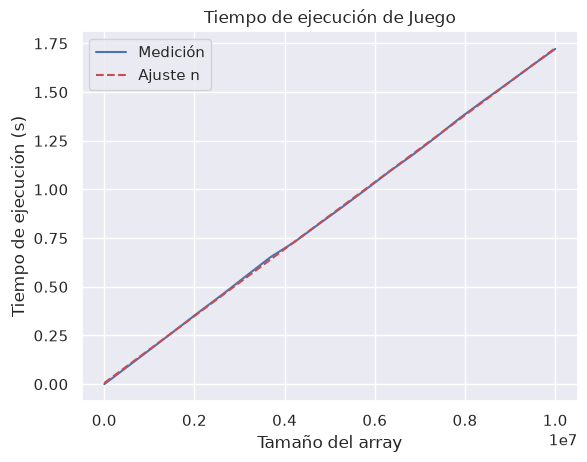

In [5]:
ax.plot(x, [c[0] * n + c[1] for n in x], 'r--', label="Ajuste n")
ax.legend()
fig

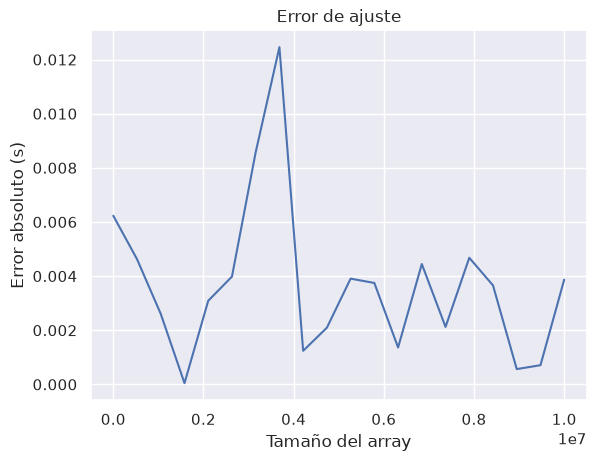

In [6]:
fig, ax = plt.subplots()
errors = [np.abs(c[0] * n + c[1] - results[n]) for n in x]
ax.plot(x, errors)
ax.set_title('Error de ajuste')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Error absoluto (s)')
None